# Wind Turbine Fault Detection Based on CNN-LSTM

**Paper**: Qi, L.; Zhang, Q.; Xie, Y.; Zhang, J.; Ke, J. *Research on Wind Turbine Fault Detection Based on CNN-LSTM*. Energies 2024, 17, 4497.

**Dataset**: CARE_To_Compare â€” Wind Farm C (58 events, 238 sensors, 10-min SCADA data)

**Adaptation**: Binary classification (normal vs anomaly) instead of 5-class. Architecture follows **Option 1** from the paper.

---

## Pipeline Overview

1. Data Loading & Exploration
2. Labeling (normal=0, anomaly=1)
3. Missing Value Handling (forward fill)
4. Feature Identification (sensor columns only)
5. Min-Max Normalization
6. XGBoost Feature Selection (top 30%)
7. Undersampling for Class Balance
8. Sliding Window Creation (36 timesteps = 6h)
9. CNN-LSTM Model (Option 1 architecture)
10. Training (Adam, CrossEntropy, batch=600, epochs=500)
11. Evaluation (Accuracy, Precision, Recall, F1)
12. Comparison with standalone CNN and LSTM
13. Visualizations & Results

## 1. Setup & Configuration

In [23]:
import os
import gc
import json
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# === Configuration matching Paper Option 1 ===
CONFIG = {
    # Paths
    "base_dir": "CARE_To_Compare/Wind Farm C",

    # Sliding window
    "window_size": 36,       # 36 timesteps = 6 hours at 10-min resolution

    # CNN-LSTM Option 1 (paper Table 2)
    "conv1_filters": 32,
    "conv1_kernel": 3,
    "pool1_size": 2,
    "conv2_filters": 64,
    "conv2_kernel": 2,
    "pool2_size": 3,
    "lstm1_units": 100,
    "lstm2_units": 80,
    "dropout_rate": 0.5,
    "dense1_units": 50,
    "dense2_units": 10,
    "num_classes": 2,        # binary: normal vs anomaly

    # Training (paper Table 3)
    "batch_size": 600,
    "epochs": 500,
    "learning_rate": 1e-3,
    "early_stopping_patience": 20,

    # Feature selection
    "xgb_top_pct": 0.30,    # top 30% features

    # Split
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,

    # Memory: cap total sliding windows to prevent OOM
    "max_total_windows": 100_000,
}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Device: cuda
Configuration:
  base_dir: CARE_To_Compare/Wind Farm C
  window_size: 36
  conv1_filters: 32
  conv1_kernel: 3
  pool1_size: 2
  conv2_filters: 64
  conv2_kernel: 2
  pool2_size: 3
  lstm1_units: 100
  lstm2_units: 80
  dropout_rate: 0.5
  dense1_units: 50
  dense2_units: 10
  num_classes: 2
  batch_size: 600
  epochs: 500
  learning_rate: 0.001
  early_stopping_patience: 20
  xgb_top_pct: 0.3
  train_ratio: 0.7
  val_ratio: 0.15
  test_ratio: 0.15
  max_total_windows: 100000


## 2. Data Loading

Load all 58 event CSVs from Wind Farm C, merge with event metadata (anomaly/normal labels).

In [24]:
base_dir = CONFIG["base_dir"]

event_info = pd.read_csv(os.path.join(base_dir, "event_info.csv"), sep=";")
feature_desc = pd.read_csv(os.path.join(base_dir, "feature_description.csv"), sep=";")

print(f"Events: {len(event_info)}")
print(f"  Anomaly: {(event_info['event_label'] == 'anomaly').sum()}")
print(f"  Normal:  {(event_info['event_label'] == 'normal').sum()}")
print(f"\nSensors described: {len(feature_desc)}")
print(f"\nEvent info columns: {list(event_info.columns)}")
display(event_info.head(10))

Events: 58
  Anomaly: 27
  Normal:  31

Sensors described: 238

Event info columns: ['asset_id', 'event_id', 'event_label', 'event_start', 'event_start_id', 'event_end', 'event_end_id', 'event_description']


,asset_id,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,50,55,anomaly,2023-10-29 11:30:00,52848,2023-11-15 15:30:00,55320,Harting plug Nacelle/HUB damaged + NCR20_HUB: ...
1,38,81,anomaly,2023-11-16 01:30:00,52704,2023-11-18 14:00:00,53067,Converter Failure from 17.11 12:30 - 18.11. 13...
2,21,47,anomaly,2023-12-22 15:00:00,52416,2023-12-27 13:40:00,53128,Failure due to Rotorbrake and Hydraulic proble...
3,2,12,anomaly,2023-06-27 00:00:00,52560,2023-07-19 15:00:00,55818,"10115 : Oil level error, two-pump mode + Oil L..."
4,34,4,anomaly,2023-07-31 10:00:00,52992,2023-08-19 10:00:00,55728,23020 : Axis 3 not ready-to-operate
5,34,18,anomaly,2023-09-13 00:00:00,51408,2023-09-16 23:50:00,51983,We had some failures (störung 24VAC Versorgung...
6,52,28,anomaly,2023-05-28 13:00:00,52704,2023-06-17 20:30:00,55629,P20_spinner_carbonbrush defekt + P20_Accumulat...
7,52,39,anomaly,2023-10-19 13:00:00,52848,2023-10-24 15:20:00,53582,15004 : Safety chain relay open + 93005 : Gear...
8,12,66,anomaly,2023-01-17 00:00:00,51696,2023-01-23 13:00:00,52638,"Pitchfailure - defect Beckhoffcard, Axis 2, re..."
9,12,15,anomaly,2023-02-06 00:00:00,51984,2023-02-23 00:00:00,54432,Randomn small failures regarding pitch resulti...


In [25]:
datasets_dir = os.path.join(base_dir, "datasets")
csv_files = sorted(
    [f for f in os.listdir(datasets_dir) if f.endswith(".csv")],
    key=lambda x: int(x.replace(".csv", ""))
)
event_label_map = dict(zip(event_info["event_id"], event_info["event_label"]))
event_start_map = dict(zip(event_info["event_id"], event_info["event_start_id"]))
event_end_map   = dict(zip(event_info["event_id"], event_info["event_end_id"]))
META_COLS = ["time_stamp", "asset_id", "id", "train_test", "status_type_id"]

def load_event(csv_file, sensor_cols, dtype_map, fill=True):
    """Load one event CSV. Uses usecols + inplace fill to avoid memory copies."""
    event_id = int(csv_file.replace(".csv", ""))
    usecols = sensor_cols + ["id"]
    df = pd.read_csv(os.path.join(datasets_dir, csv_file), sep=";",
                     dtype=dtype_map, usecols=usecols)
    event_lbl = event_label_map.get(event_id, "unknown")
    df["label"] = np.int8(0)
    if event_lbl == "anomaly":
        start_id = event_start_map.get(event_id)
        end_id   = event_end_map.get(event_id)
        if start_id is not None and end_id is not None:
            df.loc[(df["id"] >= start_id) & (df["id"] <= end_id), "label"] = np.int8(1)
    df.drop(columns=["id"], inplace=True)
    if fill:
        df.ffill(inplace=True)
        df.bfill(inplace=True)
    df["event_id"] = np.int16(event_id)
    return df

# --- Discover sensor columns ---
sample_df = pd.read_csv(os.path.join(datasets_dir, csv_files[0]), sep=";", nrows=5)
sensor_cols = [c for c in sample_df.columns if c not in META_COLS
               and sample_df[c].dtype in [np.float64, np.int64, np.float32]]
dtype_map = {c: np.float32 for c in sensor_cols}
del sample_df
print(f"Sensor feature columns: {len(sensor_cols)}")

# =============================================================
# PASS 1: Compute MinMaxScaler stats by streaming (no full concat)
# =============================================================
print("\n--- Pass 1: Computing scaler statistics ---")
col_min = np.full(len(sensor_cols), np.inf, dtype=np.float64)
col_max = np.full(len(sensor_cols), -np.inf, dtype=np.float64)
total_rows = 0
total_anomaly = 0

for i, csv_file in enumerate(csv_files):
    df = load_event(csv_file, sensor_cols, dtype_map, fill=False)
    normal_mask = df["label"].values == 0
    if normal_mask.any():
        normal_vals = df.loc[normal_mask, sensor_cols].values
        col_min = np.minimum(col_min, np.nanmin(normal_vals, axis=0))
        col_max = np.maximum(col_max, np.nanmax(normal_vals, axis=0))
        del normal_vals
    total_rows += len(df)
    total_anomaly += int(df["label"].sum())
    del df
    gc.collect()
    if (i + 1) % 20 == 0:
        print(f"  Scanned {i+1}/{len(csv_files)} files")

# Build scaler manually
col_range = col_max - col_min
col_range[col_range == 0] = 1.0  # avoid division by zero for constant features

print(f"\nTotal rows across all files: {total_rows:,}")
print(f"Anomaly rows: {total_anomaly:,}")
print(f"Normal rows: {total_rows - total_anomaly:,}")
print(f"Imbalance ratio: {(total_rows - total_anomaly) / max(total_anomaly, 1):.1f}:1")

Sensor feature columns: 952

--- Pass 1: Computing scaler statistics ---
  Scanned 20/58 files
  Scanned 40/58 files

Total rows across all files: 3,187,136
Anomaly rows: 60,897
Normal rows: 3,126,239
Imbalance ratio: 51.3:1


## 3. XGBoost Feature Selection (Paper Section 3.2.3, Step 3)

Stream through files a second time, collecting a subsample for XGBoost training. Select top 30% features.

--- Pass 2: Sampling rows for XGBoost ---
XGBoost sample: 99,992 rows, 952 features
  Class 0: 98,199  Class 1: 1,793

Total features: 952
Selected top 30%: 285 features


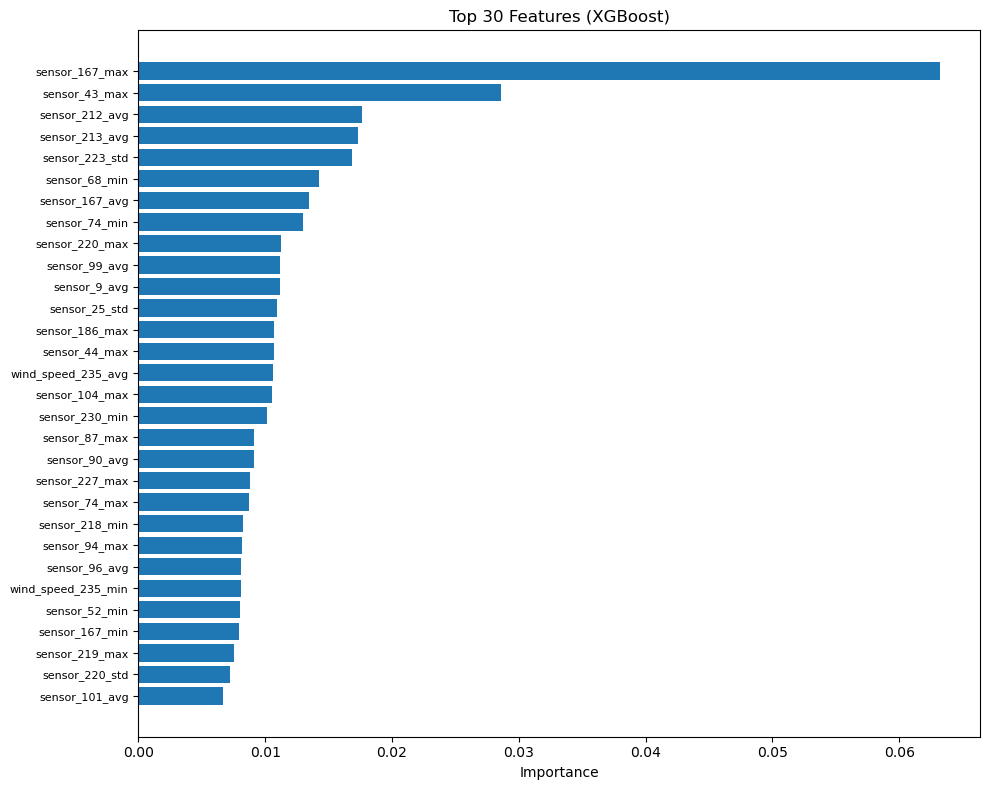


Working with 285 features from now on


In [26]:
# =============================================================
# PASS 2: Gather subsample for XGBoost feature selection
# =============================================================
print("--- Pass 2: Sampling rows for XGBoost ---")
XGB_SAMPLE_TARGET = 100_000
rows_per_file = max(1, XGB_SAMPLE_TARGET // len(csv_files))
xgb_X_parts, xgb_y_parts = [], []

for i, csv_file in enumerate(csv_files):
    df = load_event(csv_file, sensor_cols, dtype_map)
    vals = df[sensor_cols].values.astype(np.float32)
    labels = df["label"].values

    # Normalize using streaming scaler
    vals = (vals - col_min.astype(np.float32)) / col_range.astype(np.float32)
    vals = np.clip(vals, 0, None)

    # Sample rows from this file
    n_sample = min(rows_per_file, len(df))
    idx = np.random.choice(len(df), n_sample, replace=False)
    xgb_X_parts.append(vals[idx])
    xgb_y_parts.append(labels[idx])
    del df, vals, labels
    gc.collect()

X_xgb = np.concatenate(xgb_X_parts, axis=0)
y_xgb = np.concatenate(xgb_y_parts, axis=0)
del xgb_X_parts, xgb_y_parts
gc.collect()

print(f"XGBoost sample: {len(X_xgb):,} rows, {X_xgb.shape[1]} features")
print(f"  Class 0: {(y_xgb==0).sum():,}  Class 1: {(y_xgb==1).sum():,}")

n_pos = y_xgb.sum()
n_neg = len(y_xgb) - n_pos
scale_pos = n_neg / max(n_pos, 1)

xgb_model = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos, eval_metric="logloss",
    random_state=SEED, n_jobs=-1, verbosity=0,
)
xgb_model.fit(X_xgb, y_xgb)

importances = xgb_model.feature_importances_
feature_importance = pd.DataFrame({
    "feature": sensor_cols, "importance": importances
}).sort_values("importance", ascending=False)

n_top = max(1, int(len(sensor_cols) * CONFIG["xgb_top_pct"]))
selected_features = feature_importance.head(n_top)["feature"].tolist()

print(f"\nTotal features: {len(sensor_cols)}")
print(f"Selected top {CONFIG['xgb_top_pct']*100:.0f}%: {len(selected_features)} features")

fig, ax = plt.subplots(figsize=(10, 8))
top30 = feature_importance.head(30)
ax.barh(range(len(top30)), top30["importance"].values)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30["feature"].values, fontsize=8)
ax.set_xlabel("Importance")
ax.set_title("Top 30 Features (XGBoost)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Update sensor_cols to selected only; recompute scaler arrays for selected features
sel_idx = [sensor_cols.index(f) for f in selected_features]
sensor_cols = selected_features
col_min = col_min[sel_idx]
col_max = col_max[sel_idx]
col_range = col_range[sel_idx]
dtype_map = {c: np.float32 for c in sensor_cols}

del X_xgb, y_xgb, xgb_model
gc.collect()
print(f"\nWorking with {len(sensor_cols)} features from now on")

## 4. Streaming Window Creation with Undersampling (Sections 3.2.3 Steps 2,5 + Windowing)

Final pass: read each file, normalize, create sliding windows, and undersample normal windows to balance classes. This avoids ever loading the full dataset into memory.

In [27]:
# =============================================================
# PASS 3: Create windows WITH undersampling (never hold all windows)
# =============================================================
print("--- Pass 3: Creating sliding windows with inline undersampling ---")
W = CONFIG["window_size"]
n_features = len(sensor_cols)
col_min_f32 = col_min.astype(np.float32)
col_range_f32 = col_range.astype(np.float32)
MAX_WINDOWS = CONFIG["max_total_windows"]

# Phase 1: Quick scan to count anomaly/normal windows (reads 1 column only)
file_win_info = []
total_anom_win, total_norm_win = 0, 0
for csv_file in csv_files:
    event_id = int(csv_file.replace(".csv", ""))
    event_lbl = event_label_map.get(event_id, "unknown")
    id_col = pd.read_csv(os.path.join(datasets_dir, csv_file), sep=";",
                         usecols=["id"])
    n = len(id_col)
    if n < W:
        file_win_info.append((csv_file, event_id, 0, 0))
        del id_col
        continue
    labels = np.zeros(n, dtype=np.int8)
    if event_lbl == "anomaly":
        start_id = event_start_map.get(event_id)
        end_id   = event_end_map.get(event_id)
        if start_id is not None and end_id is not None:
            mask = (id_col["id"].values >= start_id) & (id_col["id"].values <= end_id)
            labels[mask] = 1
    wl = labels[W - 1:]
    n_a = int((wl == 1).sum())
    n_n = int((wl == 0).sum())
    total_anom_win += n_a
    total_norm_win += n_n
    file_win_info.append((csv_file, event_id, n_a, n_n))
    del id_col, labels, wl

print(f"Windows before undersample: anom={total_anom_win:,}  norm={total_norm_win:,}")

# Balance classes; if no anomaly windows exist, still cap to MAX_WINDOWS
if total_anom_win > 0 and total_norm_win > total_anom_win:
    keep_frac = total_anom_win / total_norm_win
else:
    keep_frac = 1.0

estimated_total = sum(n_a + int(n_n * keep_frac)
                      for _, _, n_a, n_n in file_win_info)
if estimated_total > MAX_WINDOWS:
    total_anom_fixed = sum(n_a for _, _, n_a, _ in file_win_info)
    budget_for_normal = max(0, MAX_WINDOWS - total_anom_fixed)
    keep_frac = budget_for_normal / max(total_norm_win, 1)

total_kept_est = sum(n_a + int(n_n * keep_frac)
                     for _, _, n_a, n_n in file_win_info)
est_gb = total_kept_est * W * n_features * 4 / 1e9
print(f"Normal keep fraction: {keep_frac:.6f}  |  Estimated windows: {total_kept_est:,}")
print(f"Estimated memory: {est_gb:.2f} GB  (cap={MAX_WINDOWS:,})")

# Phase 2: Collect windows in per-file chunks (avoids single giant pre-alloc)
X_parts, y_parts, eids_parts = [], [], []
win_range = np.arange(W)
ptr = 0

for i, (csv_file, event_id, n_a, n_n) in enumerate(file_win_info):
    if n_a + n_n == 0:
        continue

    df = load_event(csv_file, sensor_cols, dtype_map)
    features = df[sensor_cols].values
    labels = df["label"].values
    del df

    features = (features - col_min_f32) / col_range_f32
    np.clip(features, 0, None, out=features)

    n_win = len(features) - W + 1
    win_labels = labels[W - 1: W - 1 + n_win]

    anom_idx = np.where(win_labels == 1)[0]
    norm_idx = np.where(win_labels == 0)[0]
    n_norm_keep = int(len(norm_idx) * keep_frac)

    if n_norm_keep > 0 and len(norm_idx) > 0:
        norm_keep = np.random.choice(norm_idx, n_norm_keep, replace=False)
    else:
        norm_keep = np.array([], dtype=np.intp)

    keep_idx = np.sort(np.concatenate([anom_idx, norm_keep]))
    n_keep = len(keep_idx)

    if n_keep > 0:
        row_idx = keep_idx[:, None] + win_range[None, :]
        X_parts.append(features[row_idx])
        y_parts.append(win_labels[keep_idx])
        eids_parts.append(np.full(n_keep, event_id, dtype=np.int16))
        ptr += n_keep

    del features, labels, win_labels, keep_idx
    gc.collect()

    if (i + 1) % 10 == 0:
        print(f"  Processed {i+1}/{len(csv_files)} files ({ptr:,} windows)")

X_all = np.concatenate(X_parts, axis=0)
y_all = np.concatenate(y_parts, axis=0)
eids_all = np.concatenate(eids_parts, axis=0)
del X_parts, y_parts, eids_parts
gc.collect()

print(f"\nTotal windows after undersampling: {X_all.shape[0]:,}")
print(f"Window shape: {X_all.shape}  (samples, {W} timesteps, {n_features} features)")
print(f"Labels: 0={int((y_all==0).sum()):,}  1={int((y_all==1).sum()):,}")
print(f"Memory: {X_all.nbytes / 1e9:.2f} GB")

--- Pass 3: Creating sliding windows with inline undersampling ---
Windows before undersample: anom=60,897  norm=3,124,209
Normal keep fraction: 0.012516  |  Estimated windows: 99,971
Estimated memory: 4.10 GB  (cap=100,000)
  Processed 10/58 files (23,968 windows)
  Processed 20/58 files (42,250 windows)
  Processed 30/58 files (60,509 windows)
  Processed 40/58 files (69,794 windows)
  Processed 50/58 files (89,548 windows)

Total windows after undersampling: 99,971
Window shape: (99971, 36, 285)  (samples, 36 timesteps, 285 features)
Labels: 0=39,074  1=60,897
Memory: 4.10 GB


## 5. Undersample & Split into Train/Val/Test

In [28]:
# Undersampling already performed during window creation (Pass 3)
print(f"Windows: Normal={int((y_all==0).sum()):,}  Anomaly={int((y_all==1).sum()):,}")
print(f"Total windows: {len(X_all):,}  Memory: {X_all.nbytes / 1e9:.2f} GB")

# --- Split by event_id (70/15/15) ---
unique_eids = np.unique(eids_all)
np.random.shuffle(unique_eids)
n_tr = int(len(unique_eids) * CONFIG["train_ratio"])
n_va = int(len(unique_eids) * CONFIG["val_ratio"])

train_eids = set(unique_eids[:n_tr])
val_eids   = set(unique_eids[n_tr:n_tr + n_va])
test_eids  = set(unique_eids[n_tr + n_va:])

tr_mask = np.isin(eids_all, list(train_eids))
va_mask = np.isin(eids_all, list(val_eids))
te_mask = np.isin(eids_all, list(test_eids))

X_train, y_train = X_all[tr_mask], y_all[tr_mask]
X_val,   y_val   = X_all[va_mask], y_all[va_mask]
X_test,  y_test  = X_all[te_mask], y_all[te_mask]

del X_all, y_all, eids_all, tr_mask, va_mask, te_mask
gc.collect()

for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    print(f"{name:5s}: {len(X):,} windows | 0={int((y==0).sum()):,}  1={int((y==1).sum()):,}")

Windows: Normal=39,074  Anomaly=60,897
Total windows: 99,971  Memory: 4.10 GB
Train: 64,297 windows | 0=26,977  1=37,320
Val  : 12,854 windows | 0=5,363  1=7,491
Test : 22,820 windows | 0=6,734  1=16,086


## 6. PyTorch DataLoaders

In [29]:
def make_loader(X, y, batch_size, shuffle=True):
    tX = torch.as_tensor(X, dtype=torch.float32)
    ty = torch.as_tensor(y, dtype=torch.long)
    ds = TensorDataset(tX, ty)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      drop_last=False, pin_memory=torch.cuda.is_available())

BS = CONFIG["batch_size"]
train_loader = make_loader(X_train, y_train, BS, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BS, shuffle=False)
test_loader  = make_loader(X_test,  y_test,  BS, shuffle=False)

del X_train, y_train, X_val, y_val, X_test, y_test
gc.collect()

print(f"DataLoaders ready | batch_size={BS}")
print(f"Input shape per sample: ({W}, {n_features})")

DataLoaders ready | batch_size=600
Input shape per sample: (36, 285)


## 7. CNN-LSTM Model Architecture (Paper Section 3.3.2, Option 1)

Architecture from the paper (Table 2, Option 1):
- **Conv1D_1**: 32 filters, kernel=3, SELU -> **MaxPool1D**(2)
- **Conv1D_2**: 64 filters, kernel=2, SELU -> **MaxPool1D**(3)
- **LSTM_1**: 100 neurons -> **LSTM_2**: 80 neurons
- **Dropout**: 50%
- **Dense_1**: 50 neurons, SELU -> **Dense_2**: 10 neurons, SELU
- **Output**: 2 neurons, Softmax (binary classification)

In [30]:
class CNNLSTM(nn.Module):
    """CNN-LSTM fault detection model following Paper Option 1 (Table 2)."""

    def __init__(self, n_features, n_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, 32, kernel_size=3)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=2)
        self.pool2 = nn.MaxPool1d(kernel_size=3)
        self.lstm1 = nn.LSTM(64, 100, batch_first=True)
        self.lstm2 = nn.LSTM(100, 80, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(80, 50)
        self.fc2 = nn.Linear(50, 10)
        self.fc3 = nn.Linear(10, n_classes)
        self.selu = nn.SELU()

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (batch, features, timesteps)
        x = self.selu(self.conv1(x))
        x = self.pool1(x)
        x = self.selu(self.conv2(x))
        x = self.pool2(x)
        x = x.permute(0, 2, 1)          # (batch, T', 64) for LSTM
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :]                 # last timestep
        x = self.dropout(x)
        x = self.selu(self.fc1(x))
        x = self.selu(self.fc2(x))
        x = self.fc3(x)
        return x

model = CNNLSTM(n_features=n_features, n_classes=CONFIG["num_classes"]).to(DEVICE)
total_p = sum(p.numel() for p in model.parameters())
print(f"CNN-LSTM Model: {total_p:,} parameters")
print(model)

CNN-LSTM Model: 160,774 parameters
CNNLSTM(
  (conv1): Conv1d(285, 32, kernel_size=(3,), stride=(1,))
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(2,), stride=(1,))
  (pool2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (lstm1): LSTM(64, 100, batch_first=True)
  (lstm2): LSTM(100, 80, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=80, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=2, bias=True)
  (selu): SELU()
)


In [31]:
def train_model(model, train_loader, val_loader, config, device, model_name="CNN-LSTM"):
    """Training loop with early stopping. Returns history dict."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    for epoch in range(config["epochs"]):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * len(y_b)
            correct += (out.argmax(1) == y_b).sum().item()
            total += len(y_b)
        tr_loss, tr_acc = run_loss / total, correct / total

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                out = model(X_b)
                vl += criterion(out, y_b).item() * len(y_b)
                vc += (out.argmax(1) == y_b).sum().item()
                vt += len(y_b)
        va_loss, va_acc = vl / vt, vc / vt

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[{model_name}] Epoch {epoch+1:3d}/{config['epochs']} | "
                  f"TrLoss:{tr_loss:.4f} TrAcc:{tr_acc:.4f} | "
                  f"VaLoss:{va_loss:.4f} VaAcc:{va_acc:.4f} | "
                  f"Pat:{patience_counter}/{config['early_stopping_patience']}")

        if patience_counter >= config["early_stopping_patience"]:
            print(f"[{model_name}] Early stopping at epoch {epoch+1}")
            break

    if best_state:
        model.load_state_dict(best_state)
    return history

## 8. Training (Paper Section 3.3.3)

In [32]:
print("=" * 60)
print("Training CNN-LSTM Model")
print("=" * 60)
cnn_lstm_history = train_model(model, train_loader, val_loader, CONFIG, DEVICE, "CNN-LSTM")

Training CNN-LSTM Model
[CNN-LSTM] Epoch   1/500 | TrLoss:0.5317 TrAcc:0.7298 | VaLoss:1.7287 VaAcc:0.3881 | Pat:0/20
[CNN-LSTM] Epoch  10/500 | TrLoss:0.3027 TrAcc:0.8818 | VaLoss:2.2581 VaAcc:0.3386 | Pat:5/20
[CNN-LSTM] Epoch  20/500 | TrLoss:0.3105 TrAcc:0.8883 | VaLoss:4.7491 VaAcc:0.4004 | Pat:15/20
[CNN-LSTM] Early stopping at epoch 25


## 9. Training Curves

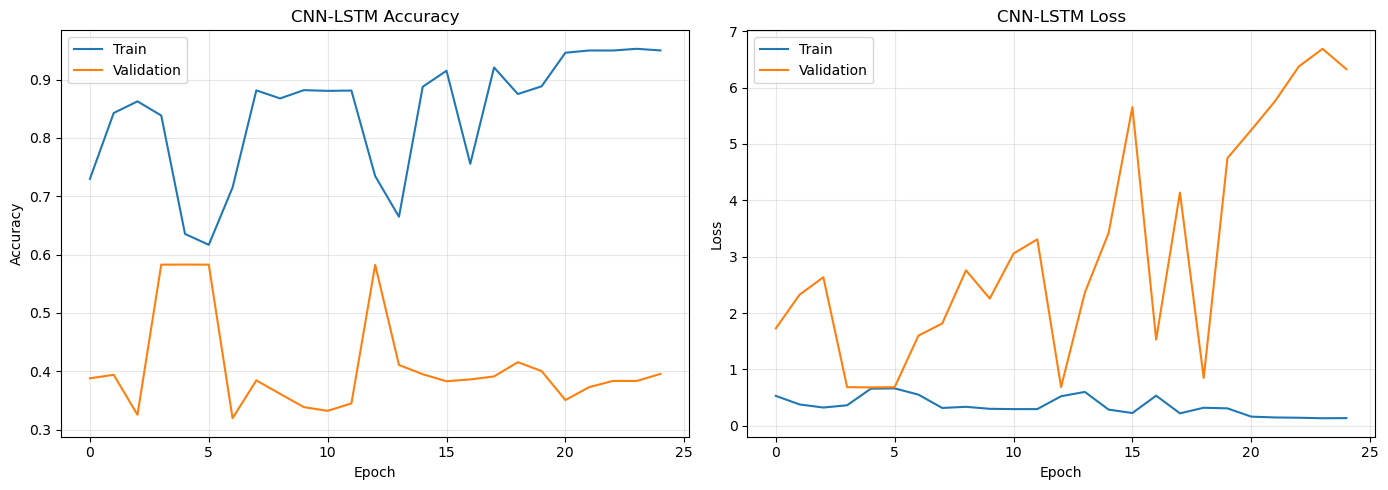

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cnn_lstm_history["train_acc"], label="Train")
axes[0].plot(cnn_lstm_history["val_acc"], label="Validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("CNN-LSTM Accuracy"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_lstm_history["train_loss"], label="Train")
axes[1].plot(cnn_lstm_history["val_loss"], label="Validation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("CNN-LSTM Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [34]:
def evaluate_model(model, loader, device):
    """Returns (y_true, y_pred, y_proba)."""
    model.eval()
    preds, labels, proba = [], [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            out = model(X_b.to(device))
            p = torch.softmax(out, dim=1)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y_b.numpy())
            proba.extend(p[:, 1].cpu().numpy())
    return np.array(labels), np.array(preds), np.array(proba)

def print_metrics(y_true, y_pred, y_proba, name="Model"):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try: auc_roc = roc_auc_score(y_true, y_proba)
    except: auc_roc = 0.0
    print(f"\n{'='*50}\n  {name} - Test Results\n{'='*50}")
    print(f"  Accuracy:  {acc*100:.2f}%")
    print(f"  Precision: {prec*100:.2f}%")
    print(f"  Recall:    {rec*100:.2f}%")
    print(f"  F1-Score:  {f1*100:.2f}%")
    print(f"  AUC-ROC:   {auc_roc:.4f}")
    print(classification_report(y_true, y_pred, target_names=["Normal","Anomaly"], zero_division=0))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc_roc": auc_roc}


  CNN-LSTM - Test Results
  Accuracy:  65.76%
  Precision: 70.27%
  Recall:    89.16%
  F1-Score:  78.59%
  AUC-ROC:   0.6750
              precision    recall  f1-score   support

      Normal       0.28      0.10      0.15      6734
     Anomaly       0.70      0.89      0.79     16086

    accuracy                           0.66     22820
   macro avg       0.49      0.50      0.47     22820
weighted avg       0.58      0.66      0.60     22820



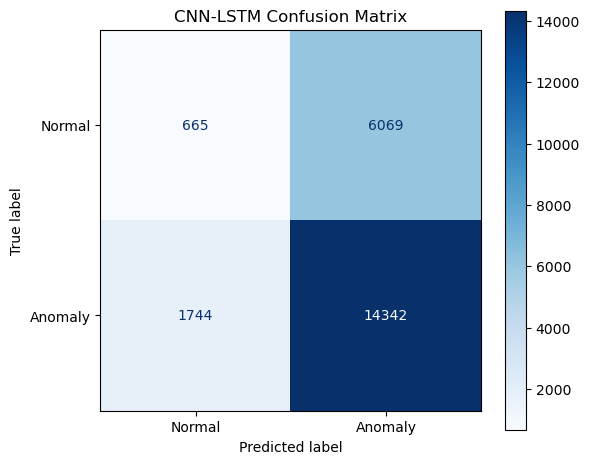

In [35]:
y_true_cnnlstm, y_pred_cnnlstm, y_proba_cnnlstm = evaluate_model(model, test_loader, DEVICE)
metrics_cnnlstm = print_metrics(y_true_cnnlstm, y_pred_cnnlstm, y_proba_cnnlstm, "CNN-LSTM")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true_cnnlstm, y_pred_cnnlstm)
ConfusionMatrixDisplay(cm, display_labels=["Normal","Anomaly"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("CNN-LSTM Confusion Matrix"); plt.tight_layout(); plt.show()

## 10. Comparison Models (Paper Section 4.2)

Train standalone CNN and LSTM models for comparison.

In [36]:
class CNNOnly(nn.Module):
    def __init__(self, n_features, n_classes=2, seq_len=36):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, 32, kernel_size=3)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=2)
        self.pool2 = nn.MaxPool1d(kernel_size=3)
        self.selu = nn.SELU()
        self.dropout = nn.Dropout(0.5)
        with torch.no_grad():
            d = torch.zeros(1, n_features, seq_len)
            d = self.pool1(self.selu(self.conv1(d)))
            d = self.pool2(self.selu(self.conv2(d)))
            flat = d.view(1, -1).shape[1]
        self.fc1 = nn.Linear(flat, 50)
        self.fc2 = nn.Linear(50, 10)
        self.fc3 = nn.Linear(10, n_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.selu(self.conv1(x)); x = self.pool1(x)
        x = self.selu(self.conv2(x)); x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.selu(self.fc1(x)); x = self.selu(self.fc2(x))
        return self.fc3(x)

class LSTMOnly(nn.Module):
    def __init__(self, n_features, n_classes=2):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, 100, batch_first=True)
        self.lstm2 = nn.LSTM(100, 80, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(80, 50)
        self.fc2 = nn.Linear(50, 10)
        self.fc3 = nn.Linear(10, n_classes)
        self.selu = nn.SELU()

    def forward(self, x):
        x, _ = self.lstm1(x); x, _ = self.lstm2(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        x = self.selu(self.fc1(x)); x = self.selu(self.fc2(x))
        return self.fc3(x)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("=" * 60, "\nTraining Standalone CNN\n" + "=" * 60)
cnn_model = CNNOnly(n_features, CONFIG["num_classes"], W).to(DEVICE)
cnn_history = train_model(cnn_model, train_loader, val_loader, CONFIG, DEVICE, "CNN")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n" + "=" * 60, "\nTraining Standalone LSTM\n" + "=" * 60)
lstm_model = LSTMOnly(n_features, CONFIG["num_classes"]).to(DEVICE)
lstm_history = train_model(lstm_model, train_loader, val_loader, CONFIG, DEVICE, "LSTM")

Training Standalone CNN
[CNN] Epoch   1/500 | TrLoss:0.5166 TrAcc:0.7318 | VaLoss:1.3689 VaAcc:0.3139 | Pat:0/20
[CNN] Epoch  10/500 | TrLoss:0.1379 TrAcc:0.9494 | VaLoss:5.3545 VaAcc:0.3496 | Pat:9/20
[CNN] Epoch  20/500 | TrLoss:0.1204 TrAcc:0.9578 | VaLoss:7.1056 VaAcc:0.4035 | Pat:19/20
[CNN] Early stopping at epoch 21

Training Standalone LSTM
[LSTM] Epoch   1/500 | TrLoss:0.4684 TrAcc:0.7668 | VaLoss:0.9456 VaAcc:0.3225 | Pat:0/20
[LSTM] Epoch  10/500 | TrLoss:0.1468 TrAcc:0.9508 | VaLoss:4.1429 VaAcc:0.3978 | Pat:9/20
[LSTM] Epoch  20/500 | TrLoss:0.0534 TrAcc:0.9856 | VaLoss:8.7642 VaAcc:0.4040 | Pat:19/20
[LSTM] Early stopping at epoch 21


## 11. Evaluate Comparison Models

In [37]:
y_true_cnn, y_pred_cnn, y_proba_cnn = evaluate_model(cnn_model, test_loader, DEVICE)
metrics_cnn = print_metrics(y_true_cnn, y_pred_cnn, y_proba_cnn, "CNN")

y_true_lstm, y_pred_lstm, y_proba_lstm = evaluate_model(lstm_model, test_loader, DEVICE)
metrics_lstm = print_metrics(y_true_lstm, y_pred_lstm, y_proba_lstm, "LSTM")


  CNN - Test Results
  Accuracy:  73.37%
  Precision: 79.09%
  Recall:    84.60%
  F1-Score:  81.75%
  AUC-ROC:   0.6932
              precision    recall  f1-score   support

      Normal       0.56      0.47      0.51      6734
     Anomaly       0.79      0.85      0.82     16086

    accuracy                           0.73     22820
   macro avg       0.67      0.66      0.66     22820
weighted avg       0.72      0.73      0.73     22820


  LSTM - Test Results
  Accuracy:  37.40%
  Precision: 66.67%
  Recall:    22.38%
  F1-Score:  33.51%
  AUC-ROC:   0.5492
              precision    recall  f1-score   support

      Normal       0.28      0.73      0.41      6734
     Anomaly       0.67      0.22      0.34     16086

    accuracy                           0.37     22820
   macro avg       0.47      0.48      0.37     22820
weighted avg       0.55      0.37      0.36     22820



In [38]:
# Summary table
comparison_df = pd.DataFrame({
    "Model": ["CNN", "LSTM", "CNN-LSTM"],
    "Accuracy (%)": [metrics_cnn["accuracy"]*100, metrics_lstm["accuracy"]*100, metrics_cnnlstm["accuracy"]*100],
    "Precision (%)": [metrics_cnn["precision"]*100, metrics_lstm["precision"]*100, metrics_cnnlstm["precision"]*100],
    "Recall (%)": [metrics_cnn["recall"]*100, metrics_lstm["recall"]*100, metrics_cnnlstm["recall"]*100],
    "F1-Score (%)": [metrics_cnn["f1"]*100, metrics_lstm["f1"]*100, metrics_cnnlstm["f1"]*100],
    "AUC-ROC": [metrics_cnn["auc_roc"], metrics_lstm["auc_roc"], metrics_cnnlstm["auc_roc"]],
})
print("Model Comparison (Paper Table 4 style):")
display(comparison_df.round(2))

Model Comparison (Paper Table 4 style):


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC-ROC
0,CNN,73.37,79.09,84.60,81.75,0.69
1,LSTM,37.40,66.67,22.38,33.51,0.55
2,CNN-LSTM,65.76,70.27,89.16,78.59,0.68


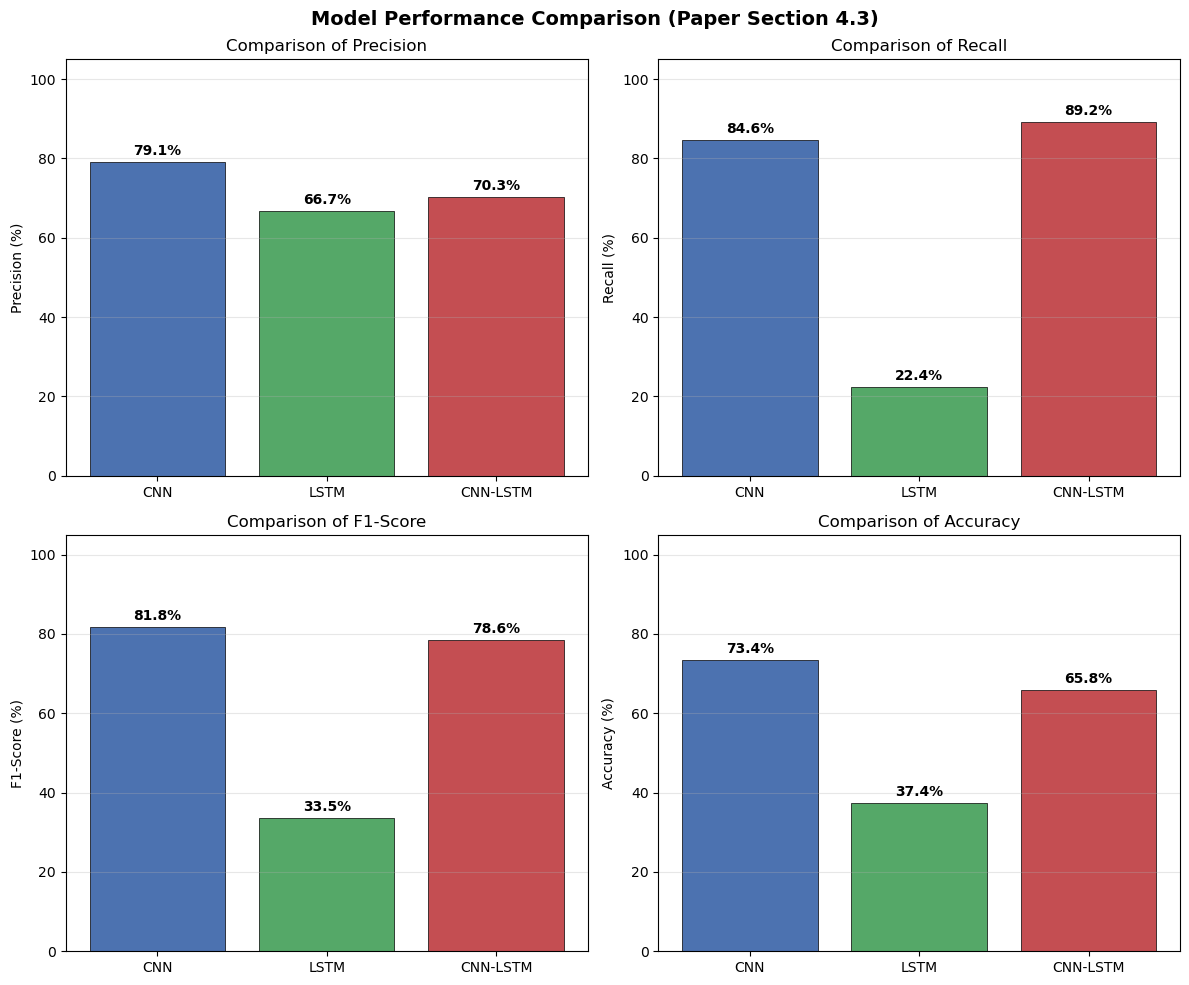

In [39]:
# Bar charts (like paper Figures 7-10)
models_names = ["CNN", "LSTM", "CNN-LSTM"]
metrics_list = [metrics_cnn, metrics_lstm, metrics_cnnlstm]
metric_keys = ["precision", "recall", "f1", "accuracy"]
metric_titles = ["Precision", "Recall", "F1-Score", "Accuracy"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, (key, title) in enumerate(zip(metric_keys, metric_titles)):
    ax = axes.ravel()[idx]
    values = [m[key] * 100 for m in metrics_list]
    bars = ax.bar(models_names, values, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_ylabel(f"{title} (%)"); ax.set_title(f"Comparison of {title}")
    ax.set_ylim(0, 105); ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.suptitle("Model Performance Comparison (Paper Section 4.3)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## 12. Confusion Matrices & ROC Curves

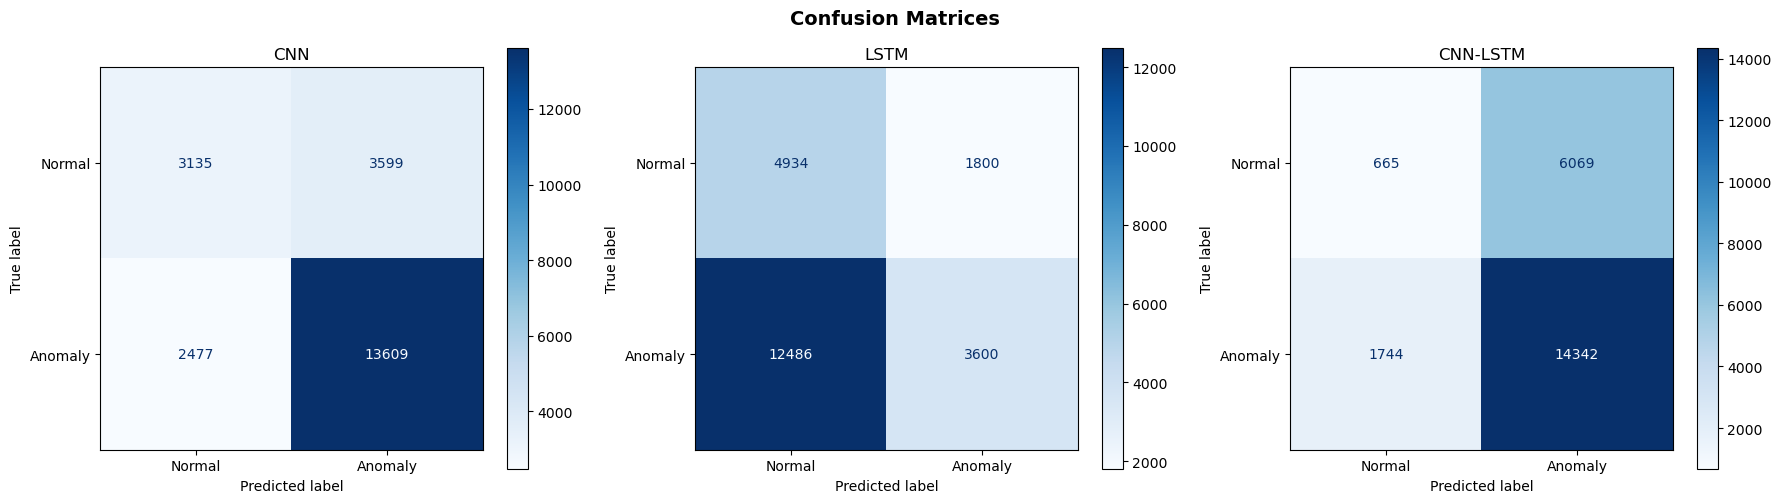

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, yt, yp, name in [
    (axes[0], y_true_cnn, y_pred_cnn, "CNN"),
    (axes[1], y_true_lstm, y_pred_lstm, "LSTM"),
    (axes[2], y_true_cnnlstm, y_pred_cnnlstm, "CNN-LSTM"),
]:
    cm = confusion_matrix(yt, yp)
    ConfusionMatrixDisplay(cm, display_labels=["Normal","Anomaly"]).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(name)
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

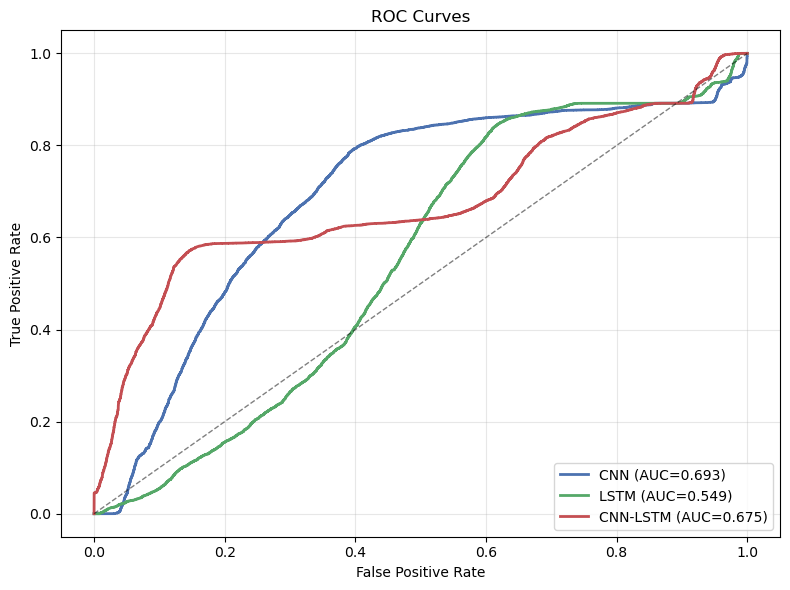

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))
for yt, yp, name, color in [
    (y_true_cnn, y_proba_cnn, "CNN", "#4C72B0"),
    (y_true_lstm, y_proba_lstm, "LSTM", "#55A868"),
    (y_true_cnnlstm, y_proba_cnnlstm, "CNN-LSTM", "#C44E52"),
]:
    fpr, tpr, _ = roc_curve(yt, yp)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves"); ax.legend(loc="lower right"); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

## 13. Training Curves Comparison

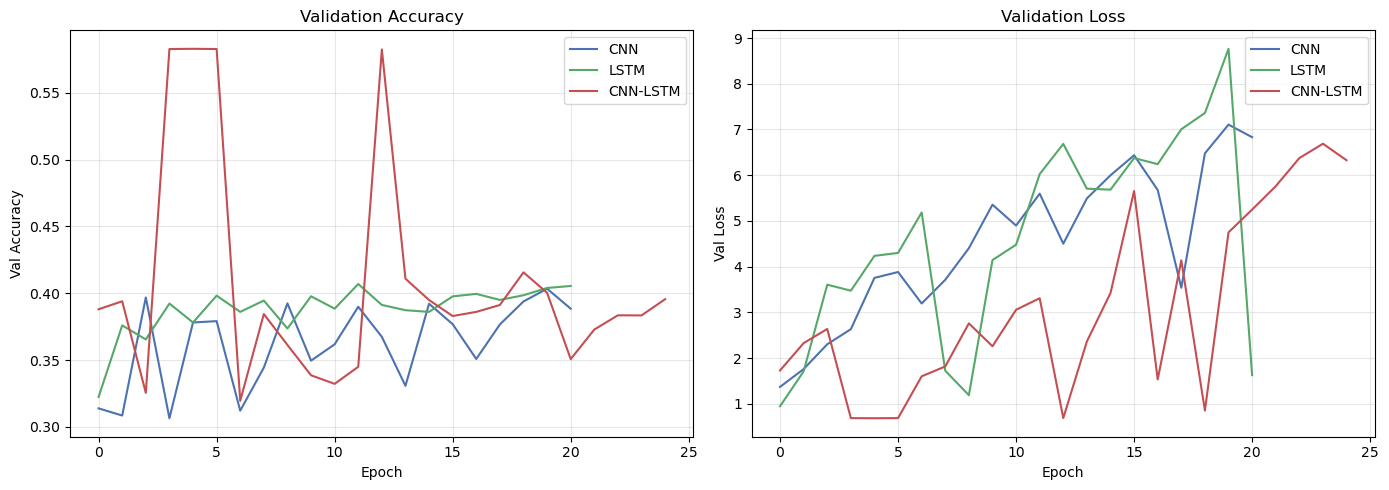

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, name, color in [
    (cnn_history, "CNN", "#4C72B0"),
    (lstm_history, "LSTM", "#55A868"),
    (cnn_lstm_history, "CNN-LSTM", "#C44E52"),
]:
    axes[0].plot(hist["val_acc"], label=name, color=color)
    axes[1].plot(hist["val_loss"], label=name, color=color)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Accuracy")
axes[0].set_title("Validation Accuracy"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Loss")
axes[1].set_title("Validation Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [43]:
save_dir = "results_cnn_lstm_paper"
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(save_dir, "cnn_lstm_model.pth"))
torch.save(cnn_model.state_dict(), os.path.join(save_dir, "cnn_model.pth"))
torch.save(lstm_model.state_dict(), os.path.join(save_dir, "lstm_model.pth"))

results = {
    "selected_features": sensor_cols,
    "n_features": len(sensor_cols),
    "window_size": W,
    "metrics": {
        "CNN": metrics_cnn,
        "LSTM": metrics_lstm,
        "CNN-LSTM": metrics_cnnlstm,
    }
}
with open(os.path.join(save_dir, "results.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to '{save_dir}/':")
for fn in os.listdir(save_dir):
    sz = os.path.getsize(os.path.join(save_dir, fn)) / 1024
    print(f"  {fn}: {sz:.1f} KB")

Results saved to 'results_cnn_lstm_paper/':
  cnn_lstm_model.pth: 632.9 KB
  cnn_model.pth: 191.7 KB
  lstm_model.pth: 853.7 KB
  results.json: 7.1 KB


---

## Conclusion

This notebook implements the CNN-LSTM fault detection pipeline from **Qi et al. (Energies 2024, 17, 4497)** adapted for **CARE_To_Compare Wind Farm C**.

### Pipeline Steps (faithful to paper):
1. **Data Preprocessing**: Missing value handling (forward fill), Min-Max normalization (streaming)
2. **Feature Selection**: XGBoost top 30% of features (Section 3.2.3)
3. **Class Balancing**: Undersampling normal windows (Section 3.2.3, Step 5)
4. **Model**: CNN-LSTM with SELU activation, Option 1 architecture (Table 2)
5. **Training**: Adam optimizer, CrossEntropy loss, batch_size=600, up to 500 epochs
6. **Evaluation**: Accuracy, Precision, Recall, F1-Score, AUC-ROC (Section 4.1)
7. **Comparison**: Standalone CNN and LSTM baselines (Section 4.2)

### Adaptation Notes:
- **Binary classification** (normal vs anomaly) instead of 5-class
- **Streaming pipeline** to handle 3M+ rows without exceeding memory
- Sliding windows of 36 timesteps (6 hours) for temporal context